In [5]:
import parcels
import math
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import trajan
import cartopy.crs as ccrs
import cartopy.feature
from datetime import datetime, timedelta

In [6]:
#Loading the dataset and matching the grid
directory_phy =  '/storage/shared/oceanparcels/input_data/MOi/'
phy_base_file =  directory_phy + 'GLO12/psy4v3r1-daily_{vector:s}_{y:04d}-{m:02d}-{d:02d}.nc' 
phy_files_U = []
phy_files_V = []

starttime = datetime(2024,11,1)
endtime = datetime(2025,1,1)
dtime = timedelta(days=1)    #je stelt hier handmatig in wat de tijdsresolutie is van je data
time = starttime
phy_file_W = directory_phy + 'GLO12/psy4v3r1-daily_{vector:s}_{y:04d}-{m:02d}-{d:02d}.nc'.format(vector = 'W', y = time.year, m = time.month, d = time.day)
while(time < endtime):
    phy_files_U.append(phy_base_file.format(vector = 'U', y = time.year, m = time.month, d = time.day))
    phy_files_V.append(phy_base_file.format(vector = 'V', y = time.year, m = time.month, d = time.day))
    time+=dtime

# pprint.pprint(phy_files_U)

mesh_file_h = directory_phy + "domain_ORCA0083-N006/PSY4V3R1_mesh_hgr.nc"   #Hiermee converteren we het grid!
mesh_file_z = directory_phy + "domain_ORCA0083-N006/PSY4V3R1_mesh_zgr.nc"
filenames_phy = {'U': {
        'lon': mesh_file_h,
        'lat': mesh_file_h,
       'depth':phy_file_W,
        'data': phy_files_U,
    }, 'V': {
        'lon': mesh_file_h,
        'lat': mesh_file_h,
       'depth':phy_file_W,
        'data': phy_files_V,
    }
}
variables_phy = {'U': 'vozocrtx',
                'V': 'vomecrty'}

c_grid_dimensions = {'lat': 'gphif',
                 'lon': 'glamf',
                 'depth':'depthw',
                 'time': 'time_counter'}

dimensions_phy = {'U': c_grid_dimensions,
                 'V': c_grid_dimensions}

#Defining a range of indices to load as fieldset to reduce computational time
indices = {'lat': range(800,2000),
           'lon': range(2300,3500)}

fieldset = parcels.FieldSet.from_nemo(filenames=filenames_phy,variables=variables_phy,dimensions=dimensions_phy, indices=indices)

In [6]:
for i in [fieldset.U, fieldset.V]:
    print(f'{i.name} with unit: {i.units}')

U with unit: <parcels.tools.converters.GeographicPolar object at 0x7f5b24b657f0>
V with unit: <parcels.tools.converters.Geographic object at 0x7f5b24b65940>


In [7]:
#Defining particle set that we can advect on fieldset

pset = parcels.ParticleSet.from_list(
    fieldset=fieldset,  # the fields on which the particles are advected
    pclass=parcels.JITParticle,  # the type of particles (JITParticle or ScipyParticle)
    lon=[-40, -40, -40, -43, -43, -43 , -46, -46, -46],   # a vector of release longitudes
    lat=[2,  5,  8, 2, 5,  8, 2, 5,  8],         # a vector of release latitudes
    depth=[0, 0, 0 , 0 , 0, 0, 0 , 0 ,0]         # a vector of release depths
)

In [8]:
print(pset)

<ParticleSet>
    fieldset   :
        <FieldSet>
            fields:
                <Field>
                    name            : 'U'
                    grid            : CurvilinearZGrid(lon=array([[-95.38, -95.29, -95.21, ...,  4.38,  4.46,  4.54],
                       [-95.38, -95.29, -95.21, ...,  4.38,  4.46,  4.54],
                       [-95.38, -95.29, -95.21, ...,  4.38,  4.46,  4.54],
                       ...,
                       [-95.42, -95.34, -95.26, ...,  4.54,  4.62,  4.71],
                       [-95.42, -95.34, -95.26, ...,  4.54,  4.62,  4.71],
                       [-95.42, -95.34, -95.26, ...,  4.54,  4.63,  4.71]], shape=(1200, 1200), dtype=float32), lat=array([[-49.93, -49.93, -49.93, ..., -49.93, -49.93, -49.93],
                       [-49.87, -49.87, -49.87, ..., -49.87, -49.87, -49.87],
                       [-49.82, -49.82, -49.82, ..., -49.82, -49.82, -49.82],
                       ...,
                       [ 37.94,  37.94,  37.94, ...,  38

/tmp/ipykernel_8839/4208098354.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko" (-> color='k'). The keyword argument will take precedence.
  pplot = ax.plot(pset.lon, pset.lat, "ko", color='red')


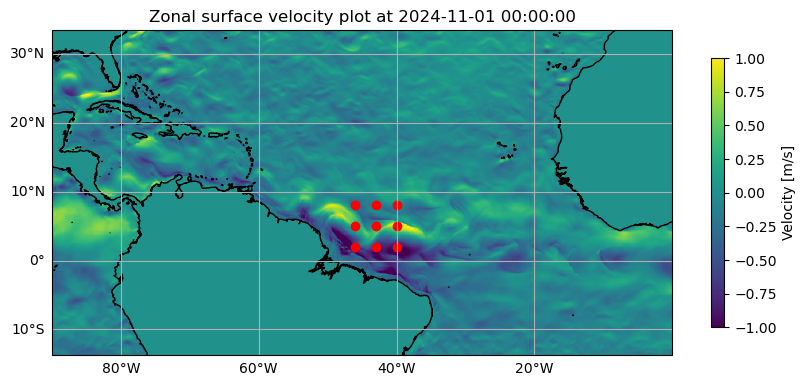

In [8]:
#By using fieldset.computeTimeChunk(), we load the first time frame of the fieldset.
fieldset.computeTimeChunk()

#Plotting velocity field of first timestep
fig1 = plt.figure(figsize = (10,7))
ax = plt.axes(projection=ccrs.PlateCarree())
vplot = ax.pcolormesh(fieldset.U.grid.lon, fieldset.U.grid.lat, fieldset.U.data[0, 0, :,:], 
                      vmin=-1, vmax=1, transform=ccrs.PlateCarree())
pplot = ax.plot(pset.lon, pset.lat, "ko", color='red')
ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_title(f'Zonal surface velocity plot at {starttime}')
ax.set_extent([-90,0,-10,25])
cbar = fig1.colorbar(vplot, ax=ax, shrink = 0.5)
cbar.set_label('Velocity [m/s]')
plt.show()

In [9]:
nparticles = 9

output_file = pset.ParticleFile(
    name="/storage/shared/oceanparcels/output_data/data_Elena/Test3_Advected_Particles.zarr",  # the file name
    outputdt=timedelta(hours=1),          # the time step of the outputs
    chunks = (nparticles, 50))     #per hoeveel tijdstappen je data wordt opgeslagen

print(output_file)

import os
print('path:', os.getcwd())

ParticleFile(name='/storage/shared/oceanparcels/output_data/data_Elena/Test3_Advected_Particles.zarr', particleset=<parcels.particleset.ParticleSet object at 0x7fd538b546e0>, outputdt=3600.0, chunks=(9, 50), create_new_zarrfile=True)
path: /storage/home/6903894/testing


In [10]:
#Defining all kernels

import custom_kernels as ck

#Custom kernel which keeps track of particle age (in minutes)
#def Age(particle, fieldset, time):
    #particle.age += particle.dt / 3600

#All kernels in a list
kernels = [ parcels.AdvectionRK4]

#Execute
pset.execute(
    kernels,        # the kernels (which define how particles move)
    runtime=timedelta(days=10),  # the total length of the run
    dt=timedelta(minutes=5),    # the timestep of the kernel
    output_file=output_file,
)

INFO: Output files are stored in /storage/shared/oceanparcels/output_data/data_Elena/Test3_Advected_Particles.zarr.
100%|██████████| 864000.0/864000.0 [05:40<00:00, 2540.26it/s]


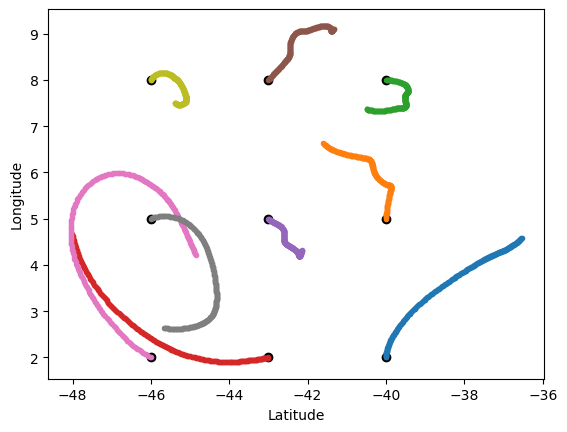

<ParticleSet>
    fieldset   :
        <FieldSet>
            fields:
                <Field>
                    name            : 'U'
                    grid            : CurvilinearZGrid(lon=array([[-95.38, -95.29, -95.21, ...,  4.38,  4.46,  4.54],
                       [-95.38, -95.29, -95.21, ...,  4.38,  4.46,  4.54],
                       [-95.38, -95.29, -95.21, ...,  4.38,  4.46,  4.54],
                       ...,
                       [-95.42, -95.34, -95.26, ...,  4.54,  4.62,  4.71],
                       [-95.42, -95.34, -95.26, ...,  4.54,  4.62,  4.71],
                       [-95.42, -95.34, -95.26, ...,  4.54,  4.63,  4.71]], shape=(1200, 1200), dtype=float32), lat=array([[-49.93, -49.93, -49.93, ..., -49.93, -49.93, -49.93],
                       [-49.87, -49.87, -49.87, ..., -49.87, -49.87, -49.87],
                       [-49.82, -49.82, -49.82, ..., -49.82, -49.82, -49.82],
                       ...,
                       [ 37.94,  37.94,  37.94, ...,  38

In [11]:
ds = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Test4_Advected_Particles_extra_kernels.zarr")

plt.plot(ds.lon.T, ds.lat.T, ".-")
plt.scatter(ds.lon.T[0], ds.lat.T[0], color='black')
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.show()

print(pset)

for i in [ds.lon, ds.lat]:
    print(f'{i.name} with unit: {i.units}')


In [15]:
#print(ds)
ds['lon']
x = ds["lon"].values
y = ds["lat"].values

distance = np.cumsum( np.sqrt(np.square(np.diff(x)) + np.square(np.diff(y))), axis=1)  # d = (dx^2 + dy^2)^(1/2)

time_in_hours = ((ds['time']-ds['time'][:,0]).astype("timedelta64[h]"))   # convert time to hours and substract the intital time from each timeseries

In [16]:
#Calculating cumulative distance of trajectories

from math import sin, cos, sqrt, atan2, radians, pi

def dist_km(lona, lonb, lata, latb):
    """
    Function to calculate the distance between 2 points in km
    Haversine formula used, which assumes the Earth is a sphere.
    source: https://stackoverflow.com/questions/19412462/getting-distance-between-two-points-based-on-latitude-longitude
    """
    
    R = 6371.0     # approximate radius of earth in km

    lat1 = radians(lata)
    lon1 = radians(lona)
    lat2 = radians(latb)
    lon2 = radians(lonb)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    distance = R * c

    return distance

def cumulative_distance_01(ds_n, nsavedir=None):
    
    # Creating the output data array:
    dist_01 = ds_n.lon.copy() * np.nan

    # Calculating the distance traveled by every particle at every timestep:
    for tt in range(0, len(ds_n.trajectory)):           #Changed ds_n.traj to ds_n.trajectory 
        lon_t = ds_n.lon[tt, :].dropna(dim='obs')
        lat_t = ds_n.lat[tt, :].dropna(dim='obs')
        
        for oo in range(1, len(lat_t)): # calculate as distance at x0 = distance at x-x0
            dist_01[tt, oo-1] = dist_km(lon_t[oo-1], lon_t[oo], lat_t[oo-1], lat_t[oo])
    
    # Calculating the cumulative distance traveled for all particle trajectories at every timestep:
    cum_dist_01 = dist_01.cumsum(dim='obs')
    
    if nsavedir:
        cum_dist_01.to_netcdf(nsavedir + "cum_dist_01.nc")
    
    return cum_dist_01

cumulative_distances_km = cumulative_distance_01(ds)

(9, 249)
(9, 249)


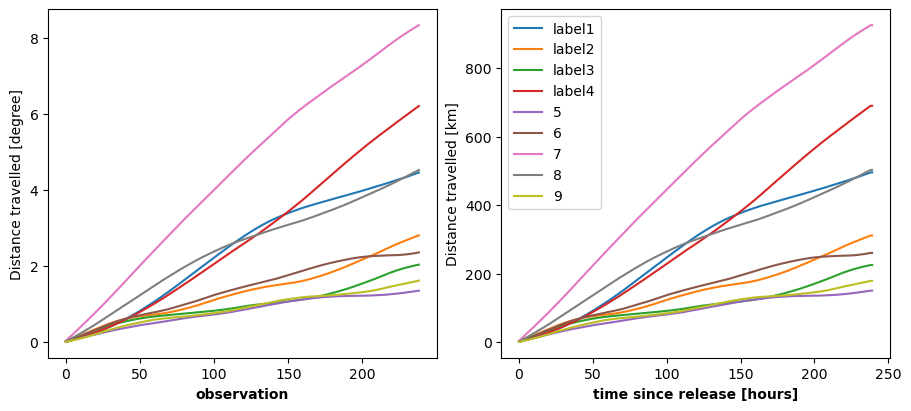

In [25]:
print(np.shape(distance))
print(np.shape(cumulative_distances_km[:,:-1]))

#Plotting distance against time that the parcels travelled
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)

ax1.set_ylabel("Distance travelled [degree]")
ax1.set_xlabel("observation", weight="bold")
d_plot = ax1.plot(distance.transpose())

ax2.set_ylabel("Distance travelled [km]")
ax2.set_xlabel("time since release [hours]", weight="bold")
d_plot_t = ax2.plot( cumulative_distances_km[:,:-10].transpose(), label=['label1', 'label2', 'label3', 'label4', '5', '6', '7', '8', '9'])
ax2.legend()
plt.show()

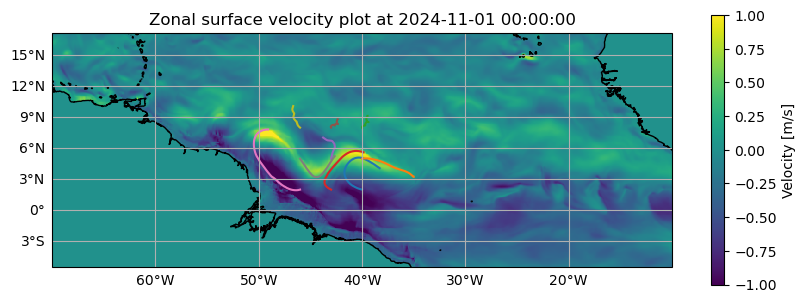

In [65]:
#Making a figure that shows the trajectories in velocity field

fig1 = plt.figure(figsize = (10,7))
ax = plt.axes(projection=ccrs.PlateCarree())
vplot = ax.pcolormesh(fieldset.U.grid.lon, fieldset.U.grid.lat, fieldset.U.data[0, 0, :,:], 
                      vmin=-1, vmax=1, transform=ccrs.PlateCarree())
#pplot = ax.scatter(pset.lon, pset.lat, color='red')
tplot = ax.plot(ds.lon.T, ds.lat.T, "-") #Transposing lon and lat arrays!
ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_title(f'Zonal surface velocity plot at {starttime}')
ax.set_extent([-70,-10,-5,15])
cbar = fig1.colorbar(vplot, ax=ax, shrink = 0.5)
cbar.set_label('Velocity [m/s]')
plt.show()

1730462400000000000 hours


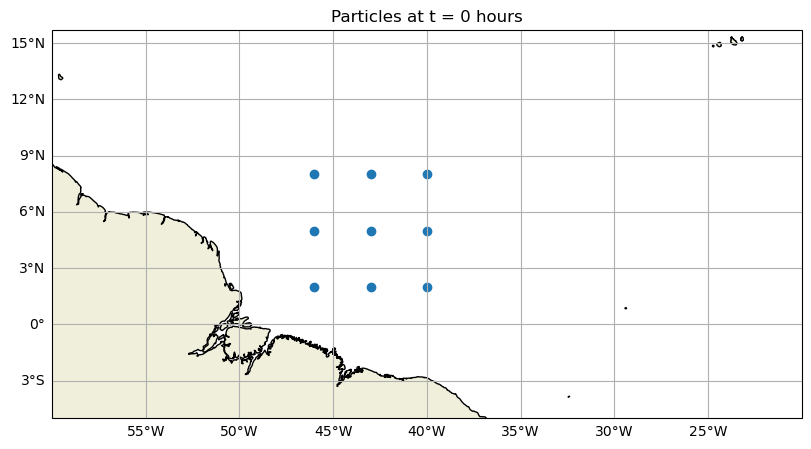

In [66]:
from IPython.display import HTML
from matplotlib.animation import FuncAnimation


fig = plt.figure(figsize = (8,5), constrained_layout=True)
ax = plt.axes(projection=ccrs.PlateCarree())

#pplot = ax.scatter(pset.lon, pset.lat, color='red')
#tplot = ax.plot(ds.lon.T, ds.lat.T, ".-") #Transposing lon and lat arrays!
ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_extent([-60,-20,-5,15])
cbar.set_label('Velocity [m/s]')

# show only every 5th output (for speed in creating the animation)
timerange = np.unique(ds["time"].values)[::5]

#print(timerange)

# Indices of the data where time = 0
time_id = np.where(ds["time"] == timerange[0])

sc = ax.scatter(ds["lon"].values[time_id], ds["lat"].values[time_id])

t = str(timerange[0].astype("timedelta64[h]")) 
title = ax.set_title(f"Particles at t = {t}")
print(t)

def animate(i):
    t = str((timerange[i]-timerange[0]).astype("timedelta64[h]")  ) 
    title.set_text(f"Particles at t = {t}")

    time_id = np.where(ds["time"] == timerange[i])
    sc.set_offsets(np.c_[ds["lon"].values[time_id], ds["lat"].values[time_id]])


anim = FuncAnimation(fig, animate, frames=len(timerange), interval=25)

In [67]:
HTML(anim.to_jshtml())